In [3]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.table as at
import sncosmo
import pickle
import numpy as np
from astropy.table import Table

import sys
sys.path.insert(0, '/home/vk9342/GausSN')  # adjust if you cloned elsewhere

# Import the gausSN, kernel, meanfuncs, lensingmodels, and utils packages
from gaussn import gausSN, kernels, meanfuncs, lensingmodels, utils


In [4]:
## Load in scarlet2 fluxes

img_index = 72358   #17462  #96679
version = '_v1'

# --- Load your Scarlet flux pickle file ---
with open('sc_fluxes/rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    flux_data = pickle.load(f)  # shape: [bands, epochs, images]

with open('sc_fluxes/rubin_scarlet_caustics_errors_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    variance_data = pickle.load(f)  # shape: [bands, epochs, images]

rubin_bands = ['lsstg', 'lsstr', 'lssti']


# sc_times = np.array([56150, 56154, 56158, 56162, 56166, 56170, 56180, 
#                      56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250])  #96679
            
# sc_times = np.array([56150, 56160, 56170, 56180, 56188, 56190, 56200,
#                      56210, 56220, 56230, 56240, 56250, 56254, 56260, 56270])  #17462


# sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130])
sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140])

# Reformat to GaussSN style table
rows = []
for b_idx, band in enumerate(rubin_bands):                    # loop over bands (g, r, i)
    for epoch_idx, (epoch_fluxes, epoch_variances) in enumerate(zip(flux_data[b_idx], variance_data[b_idx])): # loop over epochs
        for image_idx, (flux, variance) in enumerate(zip(epoch_fluxes, epoch_variances)):          # loop over image multiplicities
            
            rows.append({
                'band': band,
                'image': image_idx+1,     #GausSN uses 1, 2, 3... (and not 0, 1, 2...)
                'time': sc_times[epoch_idx],
                'flux': flux,
                'fluxerr': variance  # ???? +/0.05 to avoid error = 0
            })


data = Table(rows)
data.sort(['band', 'image', 'time'])
# output_file = 'scarlet_fluxes_'+str(img_index)+version+'_gaussn_formatted.csv'
# data.write(output_file, format='csv', overwrite=True)


# Using your existing table (with fluxerr = sqrt(|flux|)*2 + 0.05)
median_errs = {}

for band in np.unique(data['band']):
    # mask for this band, and nonzero flux values
    mask = (data['band'] == band) & (data['flux'] != 0)
    
    # compute median only for those points
    if np.any(mask):
        median_errs[band] = np.median(data['fluxerr'][mask])
    else:
        median_errs[band] = np.nan  # handle case if all fluxes are 0
    print(f"{band}: median fluxerr (excluding flux=0) = {median_errs[band]}")

# Replace all errors with that constant per band
for band in np.unique(data['band']):
    mask = data['band'] == band
    data['fluxerr'][mask] = median_errs[band]


print(data)  





lsstg: median fluxerr (excluding flux=0) = 0.3058058114742642
lssti: median fluxerr (excluding flux=0) = 0.619642896318506
lsstr: median fluxerr (excluding flux=0) = 0.5626615476793363
 band image time     flux         fluxerr      
----- ----- ---- ----------- ------------------
lsstg     1    0         0.0 0.3058058114742642
lsstg     1   10 0.018044844 0.3058058114742642
lsstg     1   20 0.027618801 0.3058058114742642
lsstg     1   30    9.089218 0.3058058114742642
lsstg     1   36   26.059883 0.3058058114742642
lsstg     1   40   29.089796 0.3058058114742642
lsstg     1   44   25.376234 0.3058058114742642
lsstg     1   48   19.162798 0.3058058114742642
lsstg     1   50    17.10462 0.3058058114742642
lsstg     1   56   10.370472 0.3058058114742642
  ...   ...  ...         ...                ...
lsstr     2   44    8.658009 0.5626615476793363
lsstr     2   48    9.463121 0.5626615476793363
lsstr     2   50    8.431289 0.5626615476793363
lsstr     2   56   7.3942165 0.5626615476793363

In [5]:
# data = data[data['band'] != 'lsstg']
# data = data[data['band'] != 'lssti']
# print(data)

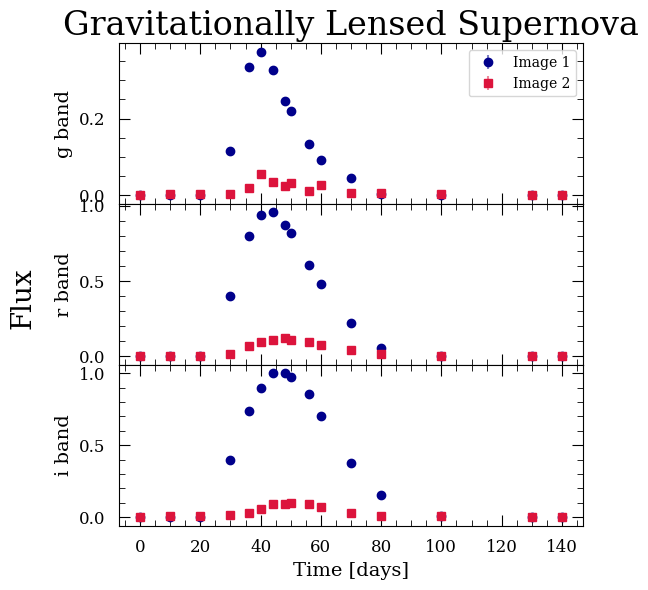

In [6]:
# NOrmalize fluxes
factor = np.max(data['flux']) - np.min(data['flux'])
data['flux'] = data['flux'] / factor
data['fluxerr'] = data['fluxerr'] / factor

# Normalize times so that the first epoch is 0
data['time'] = data['time'] - np.min(data['time'])

# Map LSST band names to what GaussSN expects
# band_map = {'g': 'lsstg', 'r': 'lsstr', 'i': 'lssti'}
# data['band'] = [band_map.get(b, b) for b in data['band']]

# Convert image index → string labels so utils.plot_object() doesn’t crash
data['image'] = [f"image_{i}" for i in data['image']]



fig, ax = utils.plot_object(data)

plt.show()




## Fitting with the GP model using a zero mean function
### Define a few functions that will be helpful for fitting/plotting

In [7]:
# Specify a prior for dynesty's nested sampler
# See the dynesty documenation for more information about how to define a ptform
def ptform(u):
    prior = u
    prior[0] = u[0]                 # A
    prior[1] = (u[1] * 30) + 10     # tau
    prior[2] = (u[2] * 40)          # delta_1,2
    prior[3] = (u[3] * 0.9) + 0.1   # beta_1,2
    return(prior)
    
# Function for kernel and lensing parameter optimization
def fit_lensedSN(data, show_plots=False):

    # Define a GP with a kernel and zero mean function
    meanfunc = meanfuncs.UniformMean([0])
    kernel = kernels.ExpSquaredKernel([0.5, 20])
    lensingmodel = lensingmodels.ConstantMagnification([0, 1])
    gp = gausSN.GP(kernel, meanfunc, lensingmodel)
        
    sampler = gp.optimize_parameters(x = data['time'], y = data['flux'], yerr = data['fluxerr'],
                                     band = data['band'], image = data['image'], fix_mean_params=True,
                                     method='dynesty', ptform=ptform, 
                                     sampler_kwargs={
                                         'sample': 'rwalk',      # MUCH better for complex posteriors
                                         'bound': 'multi',       # handles multimodal surfaces
                                         'bootstrap': 0,         # disables slow, unstable bootstrapping
                                         'nlive': 500            # increases stability, modest runtime increase
                                     })

    
    # If desired, plot the results of the parameter optimization
    if show_plots:
        plt.figure()
        param_names = ['$A$', '$\\tau$', '$\\Delta$', '$\\beta$']  # amplitude , timescale, time delay, magnification 
        fig, ax = utils.make_corner(sampler.results, param_names)
        fig.show()
        fig, ax = utils.make_traceplot(sampler.results, param_names)
        fig.show()
    
    # Return the sampler, so you can save the chains or any other information about the optimization, if desired
    return sampler

7575it [01:40, 75.56it/s, +500 | bound: 12 | nc: 1 | ncall: 158161 | eff(%):  5.122 | loglstar:   -inf < 174.143 <    inf | logz: 159.728 +/-  0.168 | dlogz:  0.001 >  0.509]


<Figure size 640x480 with 0 Axes>

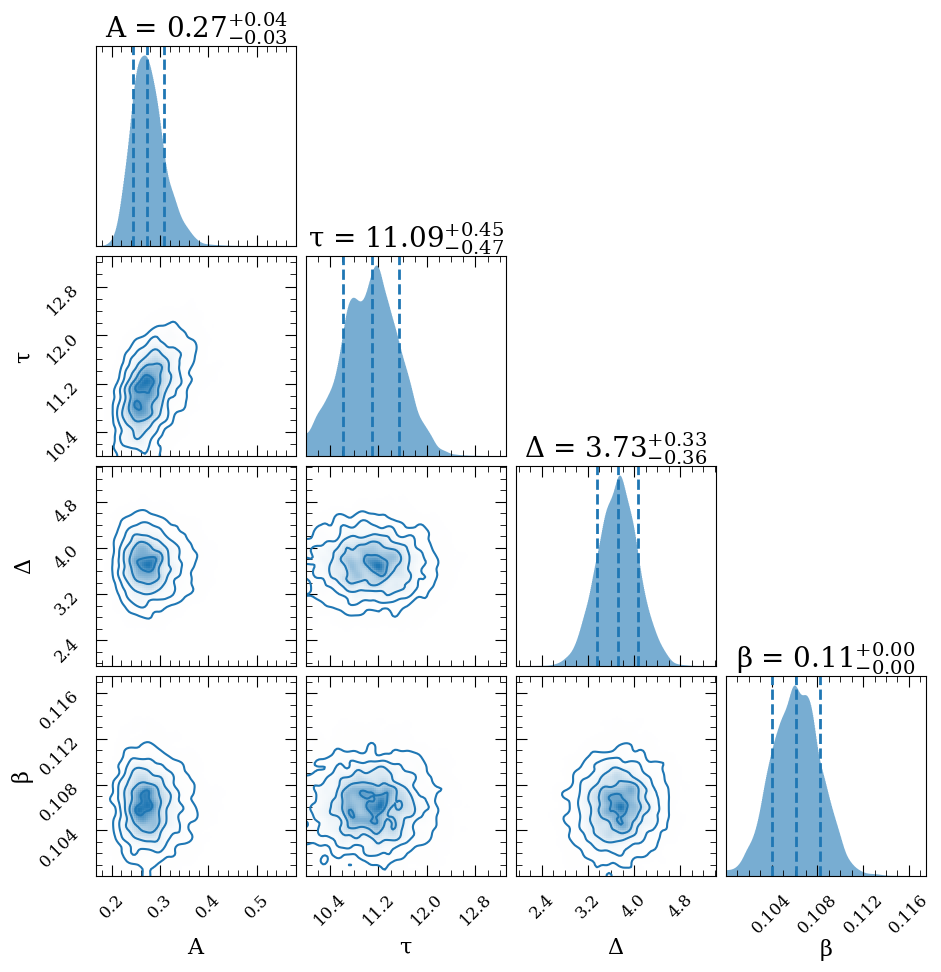

<Figure size 640x480 with 0 Axes>

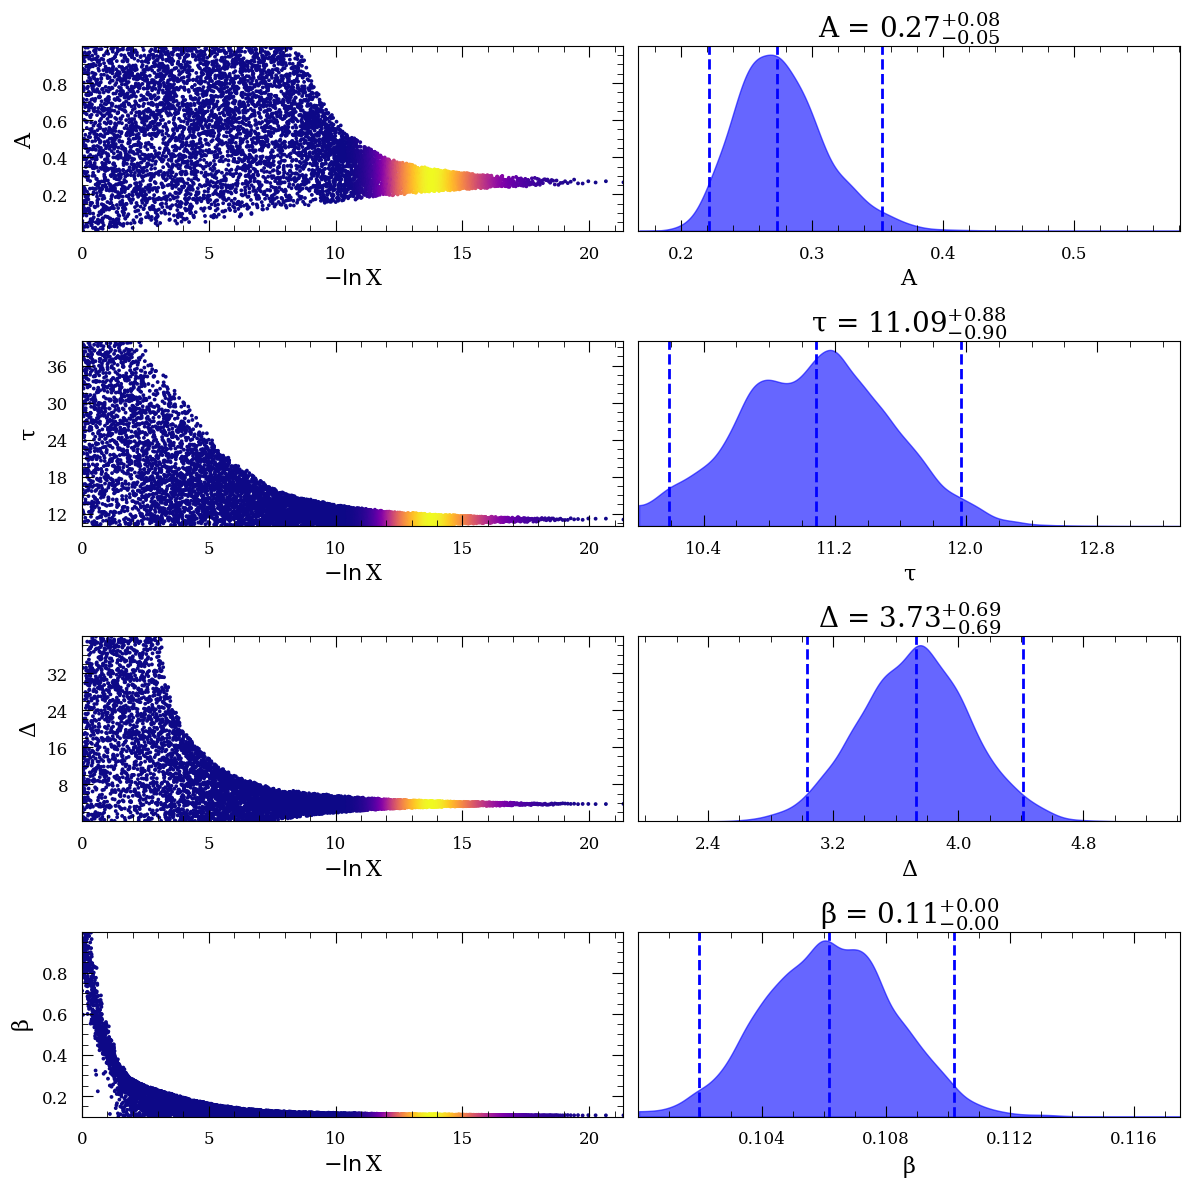

In [8]:
# Fit the light curve
sampler = fit_lensedSN(data, show_plots=True)

### Plot the fitted light curve

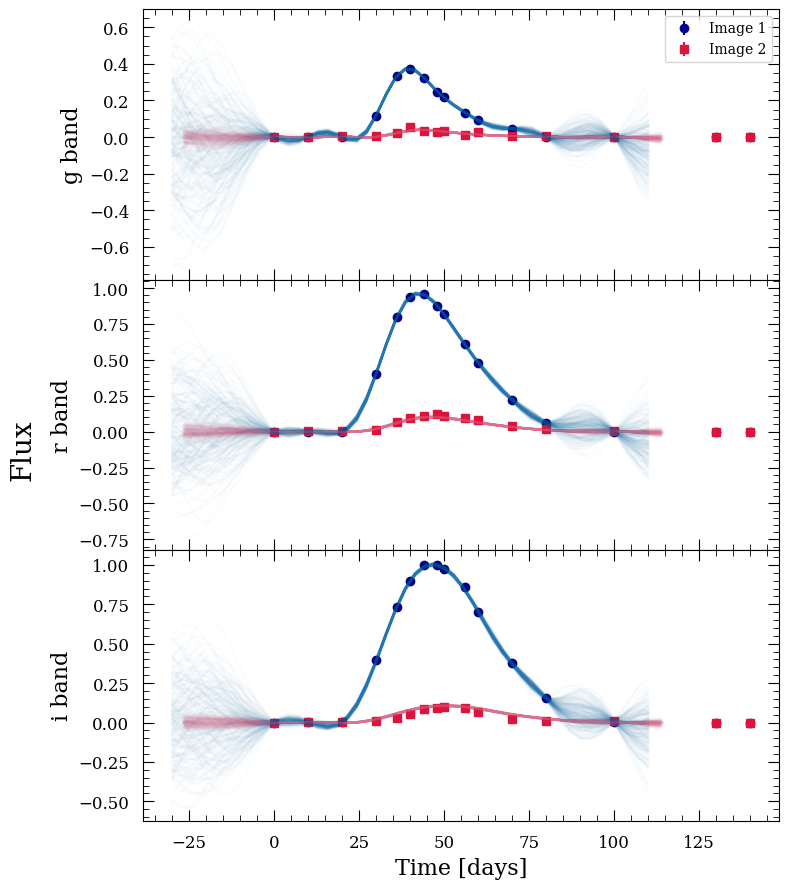

In [9]:
meanfunc = meanfuncs.UniformMean([0])
kernel = kernels.ExpSquaredKernel([0.5, 20])
lensingmodel = lensingmodels.ConstantMagnification([0, 1])

fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel, fix_mean_params=True)


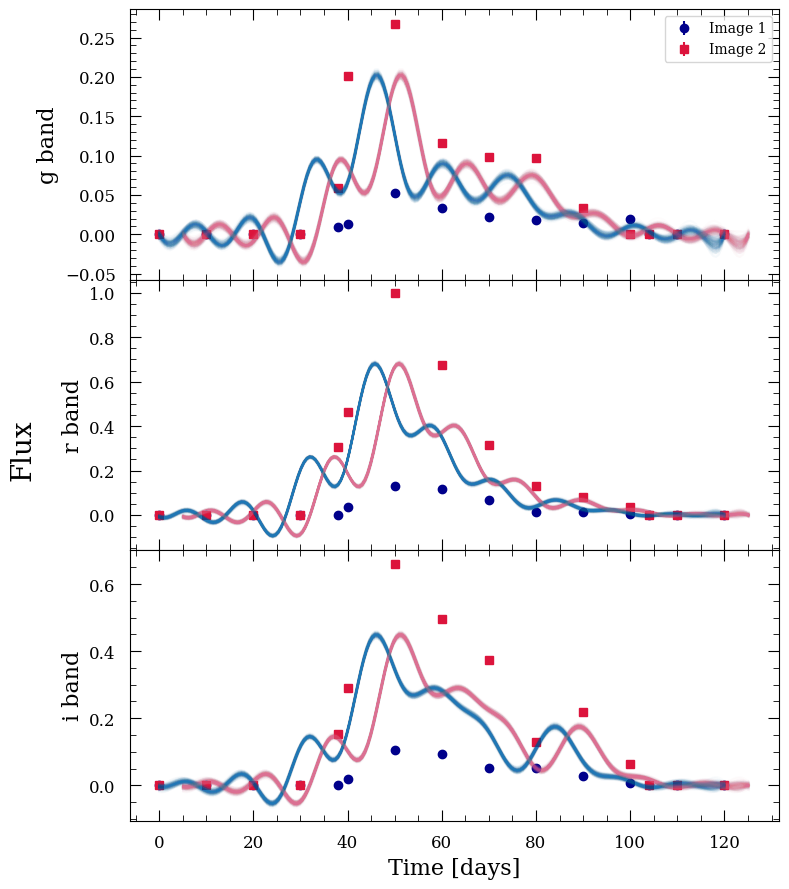

In [7]:
tmin = float(np.min(data['time']))
tmax = float(np.max(data['time']))
fig, ax = utils.plot_fitted_object(
    data,
    sampler.results,
    kernels.ExpSquaredKernel([0.5, 20]),  
    meanfuncs.UniformMean([0.0]),
    lensingmodels.ConstantMagnification([0, 1]),
    fix_mean_params=True,
    predict_times=np.linspace(tmin, tmax, 200)  # <— clamp to data range
)

# Result from default GausSN setup

/home/vk9342/GausSN/gaussn/utils.py:221: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_vals = np.random.multivariate_normal(mean=exp, cov=cov, size=1)


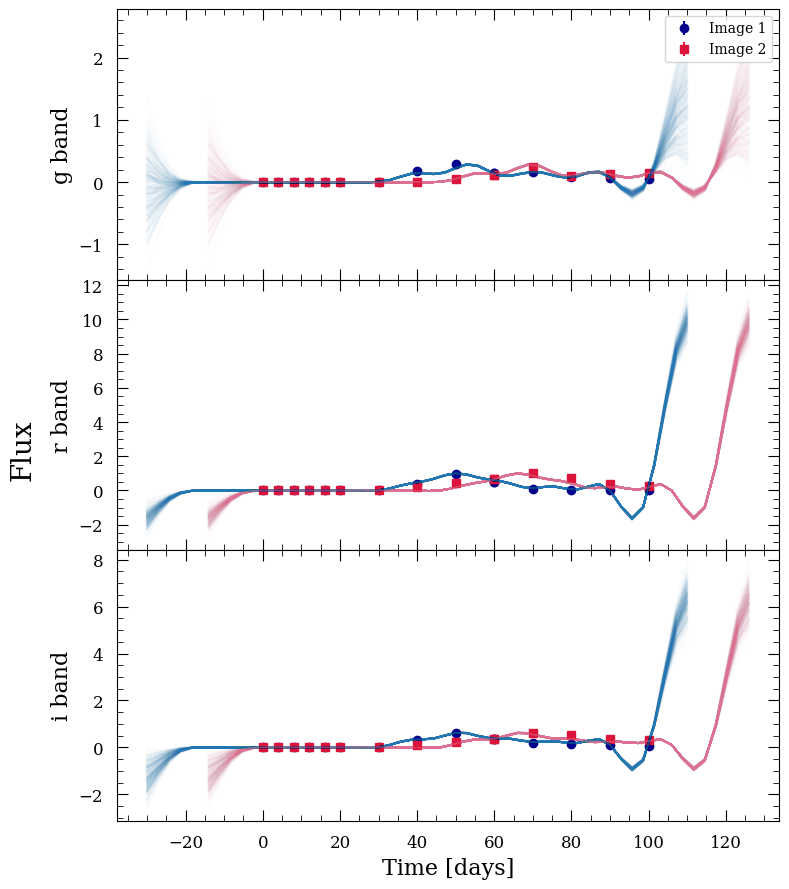

In [17]:
## OLD plot before modiifying code

meanfunc = meanfuncs.UniformMean([0])
kernel = kernels.ExpSquaredKernel([0.5, 20])
lensingmodel = lensingmodels.ConstantMagnification([0, 1])

fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel, fix_mean_params=True)
